# Import Libraries

In [11]:
import pandas as pd

# Load Dataset

In [12]:
df = pd.read_csv('D:\Fintech_AI_Project\creditcard.csv')

In [13]:
# Check shape
print(df.shape)

(284807, 31)


In [14]:
# Check missing values
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [15]:
# Check duplicates
print("Duplicates:", df.duplicated().sum())

Duplicates: 1081


In [16]:
# Remove duplicates
df = df.drop_duplicates()

In [17]:
# Verify data types
print(df.dtypes)

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [18]:
#Basic statistics
print(df.describe())

                Time             V1             V2             V3  \
count  283726.000000  283726.000000  283726.000000  283726.000000   
mean    94811.077600       0.005917      -0.004135       0.001613   
std     47481.047891       1.948026       1.646703       1.508682   
min         0.000000     -56.407510     -72.715728     -48.325589   
25%     54204.750000      -0.915951      -0.600321      -0.889682   
50%     84692.500000       0.020384       0.063949       0.179963   
75%    139298.000000       1.316068       0.800283       1.026960   
max    172792.000000       2.454930      22.057729       9.382558   

                  V4             V5             V6             V7  \
count  283726.000000  283726.000000  283726.000000  283726.000000   
mean       -0.002966       0.001828      -0.001139       0.001801   
std         1.414184       1.377008       1.331931       1.227664   
min        -5.683171    -113.743307     -26.160506     -43.557242   
25%        -0.850134      -0.6898

# EDA Overview

In [19]:
# Class distribution
print(df['Class'].value_counts())

# Fraud percentage
fraud_pct = df['Class'].mean()*100
print(f"Fraud Percentage: {fraud_pct:.4f}%")

Class
0    283253
1       473
Name: count, dtype: int64
Fraud Percentage: 0.1667%


In [20]:
df.to_csv("D:\\Fintech_AI_Project\\data\\creditcard_cleaned.csv", index=False)

OSError: Cannot save file into a non-existent directory: 'D:\Fintech_AI_Project\data'

In [ ]:
import os

print(os.path.exists("c:\\Fintech_AI_Project\\data\\creditcard_cleaned.csv"))

False


In [ ]:
print(df.shape)

(283726, 32)


# Visualization - Class Distribution

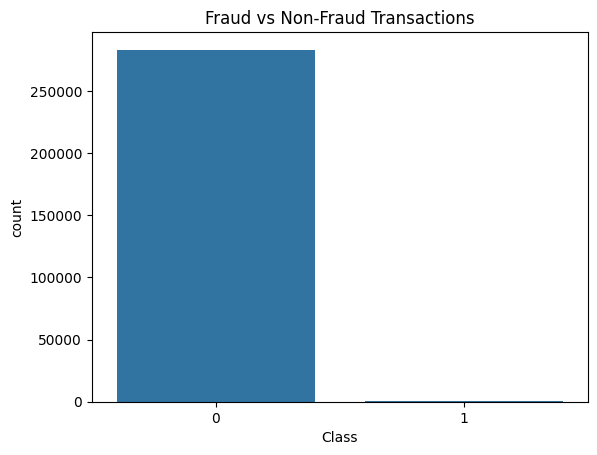

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

# Visualization - Transaction Amount

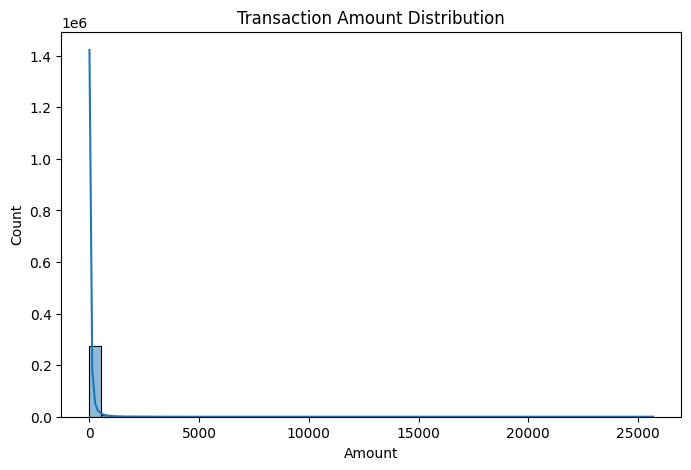

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Transaction Amount Distribution')
plt.show()  

# Visualization - Correlation Heatmap

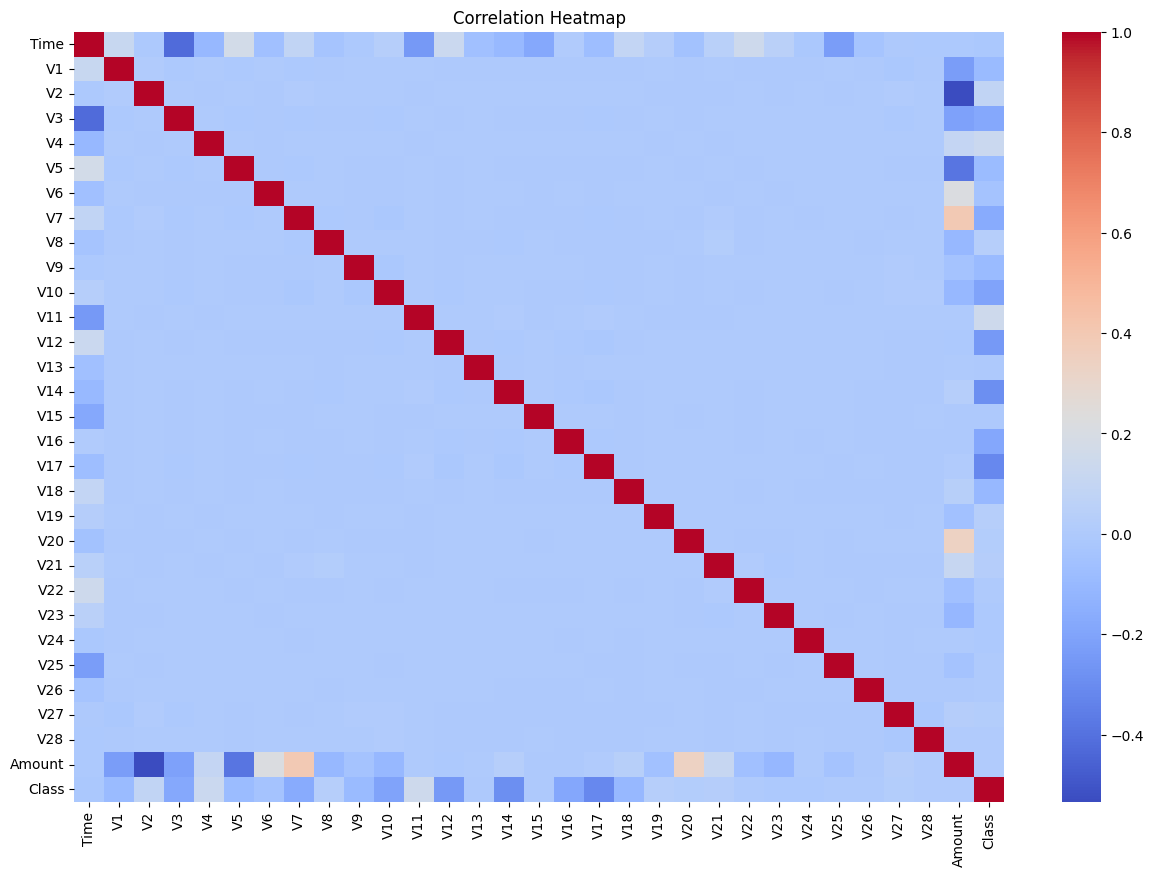

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Visualiztion - Fraud Amount Comparison

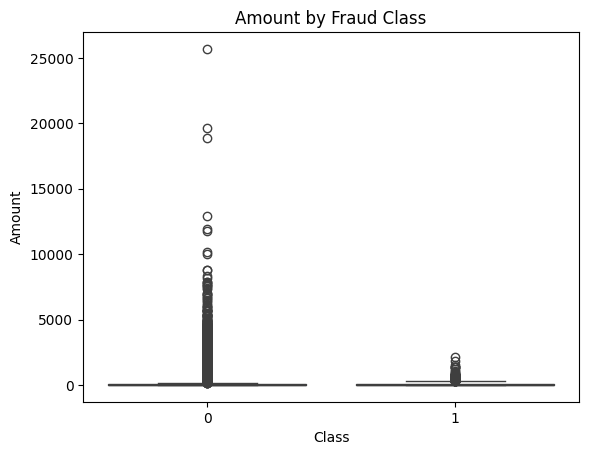

In [ ]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Amount by Fraud Class')
plt.show()  

# KPI

In [ ]:
# KPI 1 — Total Transactions
total_transactions = len(df)
print("Total Transactions:", total_transactions)

# KPI 2 — Fraud Transactions
fraud_transactions = df[df['Class']==1].shape[0]
print("Fraud Transactions:", fraud_transactions)

# KPI 3 — Fraud Percentage
fraud_percentage = round((fraud_transactions / total_transactions) * 100, 4)
print("Fraud Percentage:", fraud_percentage,"%")

# KPI 4 — Average Transaction Amount
average_transaction_amount = df['Amount'].mean()

# KPI 5 — Maximum Fraud Amount
maximum_fraud_amount = df[df['Class']==1]['Amount'].max()

# KPI 6 — Fraud vs Non-Fraud Ratio
fraud_ratio = round((fraud_transactions / total_transactions) * 100, 4)

# KPI 7 — Fraud Amount Sum
fraud_amount_sum = df[df['Class']==1]['Amount'].sum()


Total Transactions: 283726
Fraud Transactions: 473
Fraud Percentage: 0.1667 %


# EDA

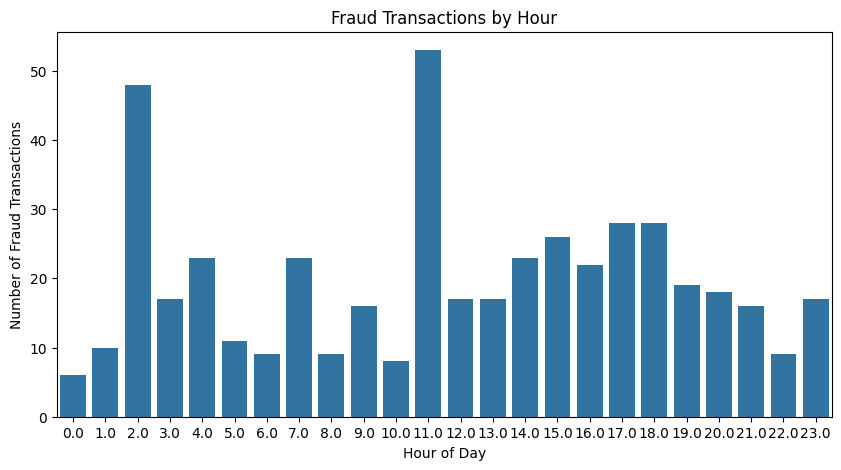

In [ ]:
# Fraud Transactions by Hour

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create Hour column
df['Hour'] = (df['Time'] // 3600) % 24

plt.figure(figsize=(10,5))

sns.countplot(
    x='Hour',
    data=df[df['Class']==1]
)

plt.title('Fraud Transactions by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Fraud Transactions')

plt.show()

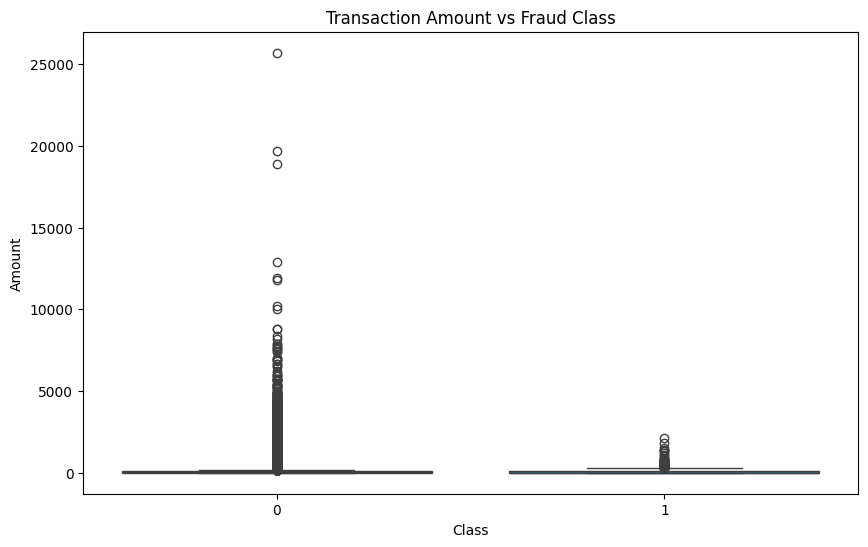

In [ ]:
# Boxplot for Transaction Amount

plt.figure(figsize=(10,6))

sns.boxplot(
    x='Class',
    y='Amount',
    data=df
)

plt.title('Transaction Amount vs Fraud Class')

plt.show()

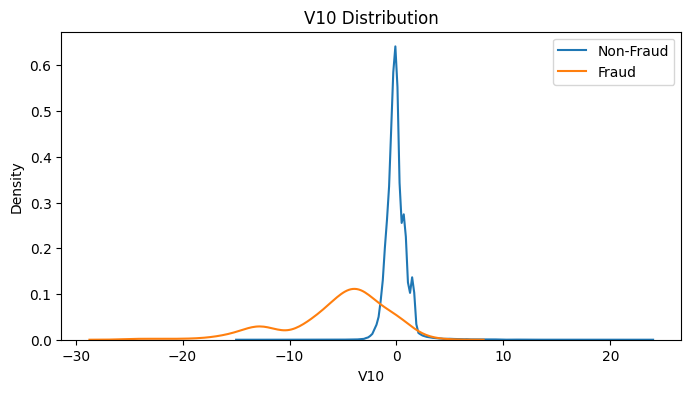

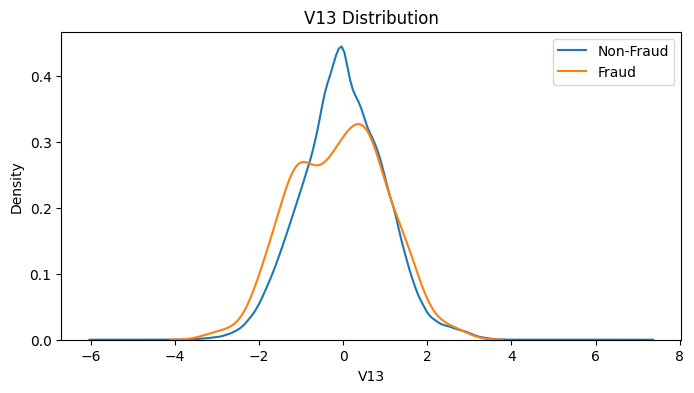

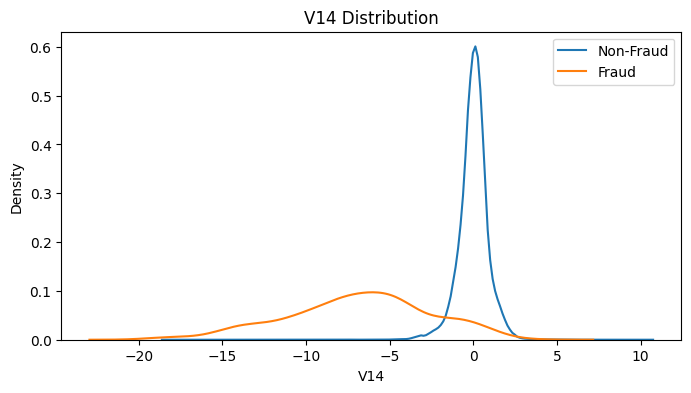

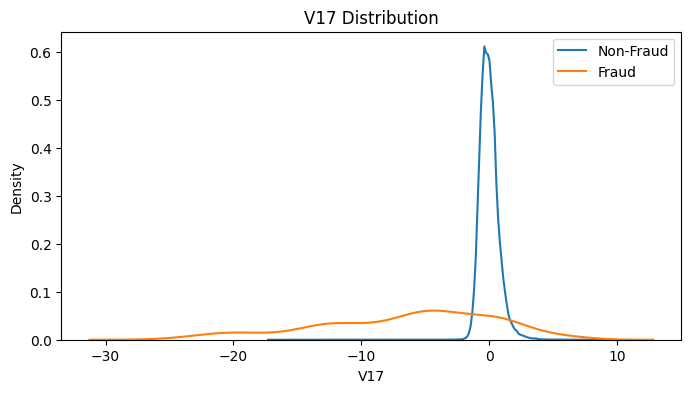

In [ ]:
# PCA Feature Comparison (V1–V28)

important_features = ['V10','V13','V14','V17']

for feature in important_features:

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        data=df[df['Class']==0],
        x=feature,
        label='Non-Fraud'
    )

    sns.kdeplot(
        data=df[df['Class']==1],
        x=feature,
        label='Fraud'
    )

    plt.title(f'{feature} Distribution')
    plt.legend()

    plt.show()

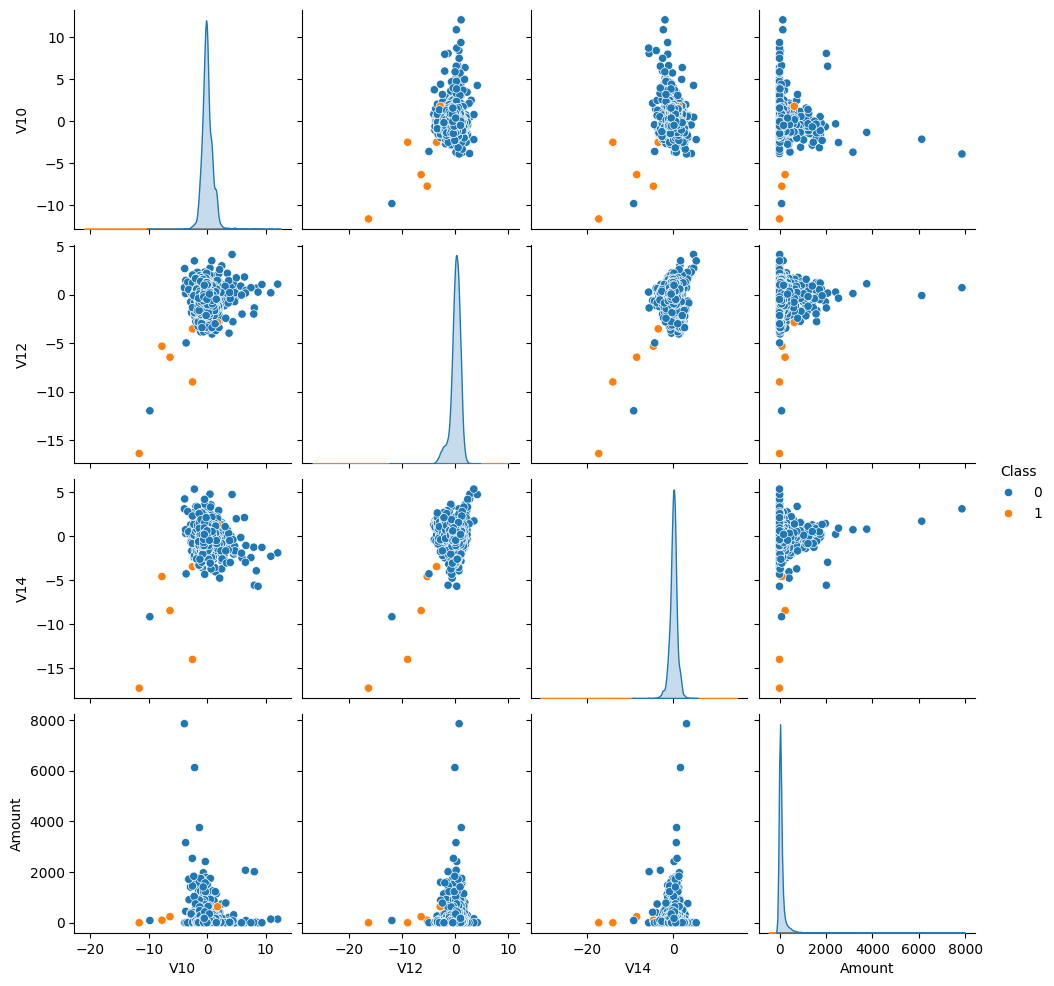

In [ ]:
# Pairplot of Important Features

sample_df = df.sample(
    n=5000,
    random_state=42
)

features = [
    'V10',
    'V12',
    'V14',
    'Amount',
    'Class'
]

sns.pairplot(
    sample_df[features],
    hue='Class'
)

plt.show()

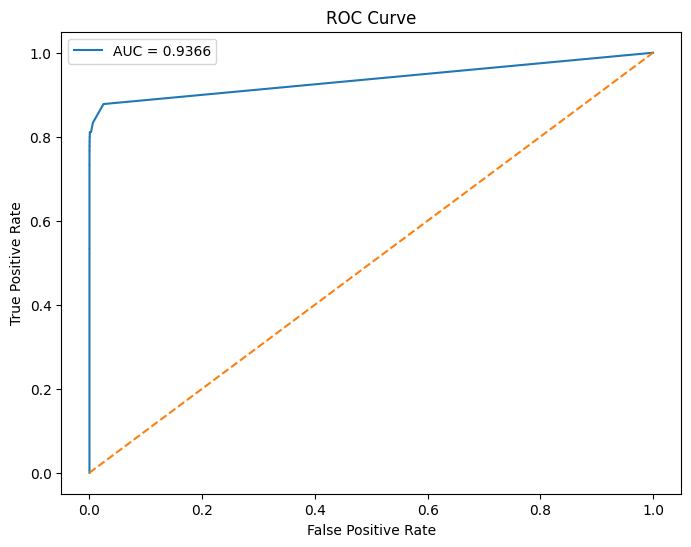

In [ ]:
# ROC Curve(After Model Training)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split


X = df.drop('Class', axis=1)
y = df['Class']
 
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')

plt.plot(
    [0,1], 
    [0,1], 
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()

plt.show()

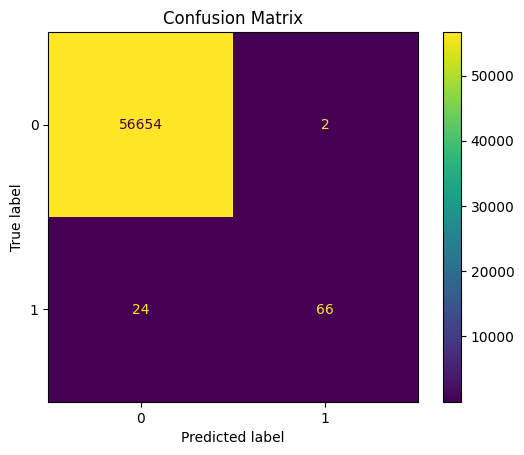

In [ ]:
# COnfusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm)

disp.plot()

plt.title('Confusion Matrix')

plt.show()



In [ ]:
# After EDA, create these KPIs

total_transactions = len(df)

fraud_transactions = len(df[df['Class']==1])

non_fraud_transactions = len(df[df['Class']==0])

fraud_rate = ( fraud_transactions / total_transactions) * 100

avg_amount = df['Amount'].mean()

total_fraud_amount = (
    df[df['Class']==1]['Amount'].sum()
)

print("Total Transactions:", total_transactions)
print("Fraud Transactions:", fraud_transactions)
print("Non-Fraud Transactions:", non_fraud_transactions)
print("Fraud Rate:", round(fraud_rate,4),"%")
print("Average Amount:", round(avg_amount,2))
print("Total Fraud Amount:", round(total_fraud_amount,2))



Total Transactions: 283726
Fraud Transactions: 473
Non-Fraud Transactions: 283253
Fraud Rate: 0.1667 %
Average Amount: 88.47
Total Fraud Amount: 58591.39


# Apply SMOTE(Synthetic Minority Oversampling Technique)

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


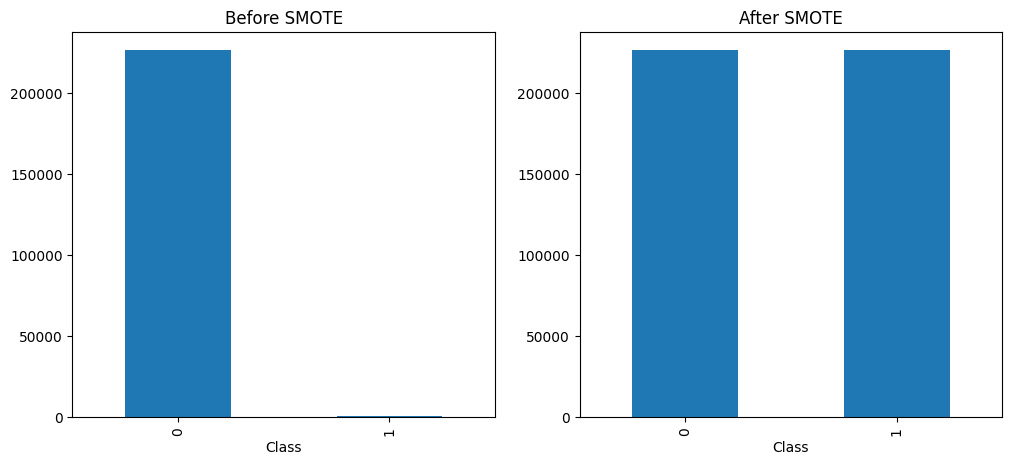

In [ ]:
# Visualize SMOTE Effecct

import matplotlib.pyplot as plt

before = y_train.value_counts()
after = y_train_smote.value_counts()

fig, axes = plt.subplots(1,2, figsize=(12,5))

before.plot(
    kind='bar',
    ax=axes[0],
    title='Before SMOTE'
)

after.plot(
    kind='bar',
    ax=axes[1],
    title='After SMOTE'
)

plt.show()


In [ ]:
# Train Models

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

C:\Users\office\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
y_train_smote.shape[0]

453204

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)



,n_estimators,30
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Evaluate Models

from sklearn.metrics import classification_report, confusion_matrix
y_pred = rf.predict(X_test)

print(
    classification_report(y_test, y_pred)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.69      0.81        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.90     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(
    importance.head(10)
)

   Feature  Importance
14     V14    0.196643
10     V10    0.144563
12     V12    0.107950
4       V4    0.080432
11     V11    0.075824
17     V17    0.068759
3       V3    0.048101
16     V16    0.036978
7       V7    0.030595
2       V2    0.024684


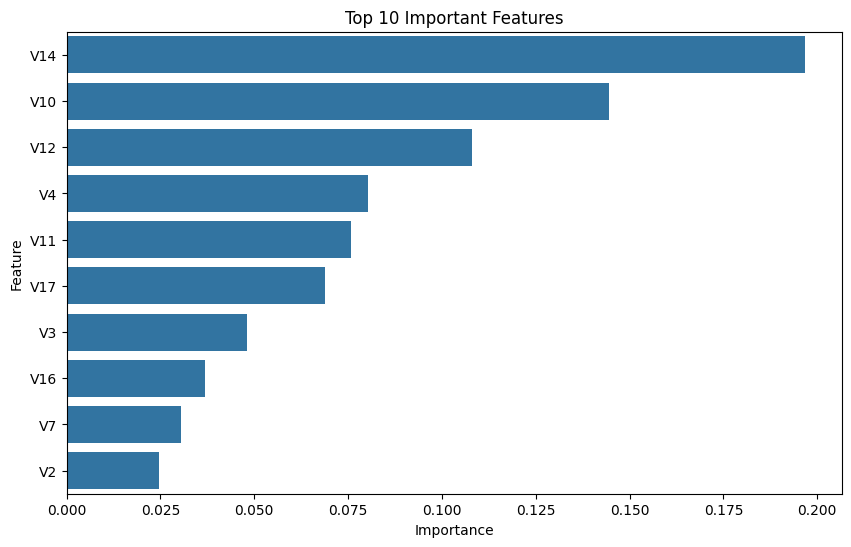

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features')

plt.show()

In [ ]:
# Save model

import joblib

joblib.dump(
    rf,
    'fraud_detection_model.pkl'
)

print("Model Saved!")

Model Saved!


In [ ]:
# Load model later

import joblib

model = joblib.load(
    'fraud_detection_model.pkl'
)

print("Model Loaded!")

Model Loaded!


In [ ]:
# Make predictions with loaded model

prediction = model.predict(X_test)

print(prediction[:10])

[0 0 0 0 0 0 0 0 0 0]


In [ ]:
import numpy as np

unique, counts = np.unique(prediction, return_counts=True)

print(dict(zip(unique, counts)))

{np.int64(0): np.int64(56678), np.int64(1): np.int64(68)}


In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.69      0.81        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.90     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
y_prob = model.predict_proba(X_test)

print(y_prob[:5])

[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.69      0.81        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.90     56746
weighted avg       1.00      1.00      1.00     56746

[[56649     2]
 [   29    66]]


# Section 1: Project Header

In [ ]:
import streamlit as st

print(st.__version__)

1.58.0
